# 03 - Model Evaluation

## Dataset: hourlySteps_clean.csv

### Programación para la Ciencia de Datos

## Objetivo
Evaluar rigurosamente los modelos supervisados implementados utilizando múltiples métricas, validación cruzada e interpretación comparativa.

### Criterios cubiertos
- Validación cruzada robusta
- Accuracy
- Precision
- Recall
- F1-Score
- Matrices de confusión
- Classification Report
- Comparación entre modelos
- Interpretación técnica

In [1]:
# ========================================
# LIBRERÍAS
# ========================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42

sns.set_style("whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ========================================
# CARGA DEL DATASET
# ========================================

df = pd.read_csv("hourlySteps_clean.csv")

print("Dimensiones del dataset:")
print(df.shape)

df.head()

Dimensiones del dataset:
(21273, 7)


,Id,ActivityHour,StepTotal,Hora,Dia,FinDeSemana,StepTotal_scaled
0,1.503960e+09,2016-03-12 00:00:00,0.0,0,Saturday,1,-0.428148
1,1.503960e+09,2016-03-12 01:00:00,0.0,1,Saturday,1,-0.428148
2,1.503960e+09,2016-03-12 02:00:00,0.0,2,Saturday,1,-0.428148
3,1.503960e+09,2016-03-12 03:00:00,0.0,3,Saturday,1,-0.428148
4,1.503960e+09,2016-03-12 04:00:00,0.0,4,Saturday,1,-0.428148


# Construcción de Variable Objetivo

Se transforma el problema en clasificación supervisada.

In [3]:
def classify_activity(steps):

    if steps < 100:
        return "Low Activity"

    elif steps < 1000:
        return "Medium Activity"

    else:
        return "High Activity"

df["ActivityLevel"] = df["StepTotal"].apply(classify_activity)

df["ActivityLevel"].value_counts()

,count
ActivityLevel,
Low Activity,13060
Medium Activity,6569
High Activity,1644


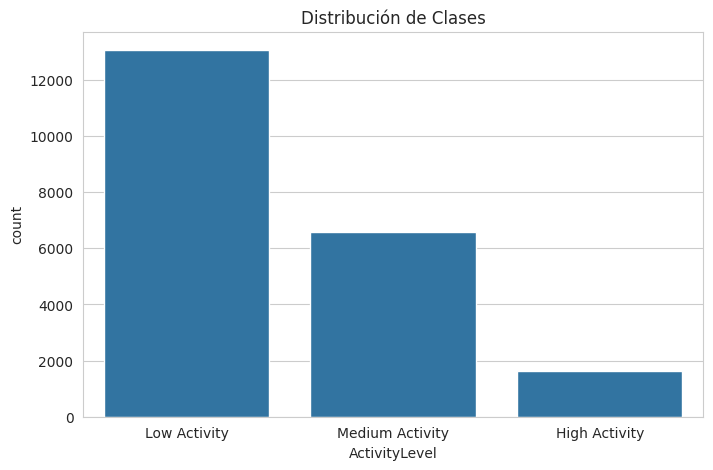

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="ActivityLevel"
)

plt.title("Distribución de Clases")

plt.show()

# Preparación de Variables

In [5]:
features = [
    "Hora",
    "FinDeSemana",
    "StepTotal_scaled"
]

X = df[features]

y = df["ActivityLevel"]

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['High Activity' 'Low Activity' 'Medium Activity']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (17018, 3)
Test: (4255, 3)


# Definición de Modelos

In [7]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=RANDOM_STATE))
    ]),

    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(random_state=RANDOM_STATE))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(random_state=RANDOM_STATE))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])
}

# Validación Cruzada

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y_encoded,
        cv=cv,
        scoring="accuracy"
    )

    cv_results[name] = scores

    print("="*60)
    print(name)
    print(f"Mean Accuracy: {scores.mean():.4f}")
    print(f"Std Dev: {scores.std():.4f}")

Logistic Regression
Mean Accuracy: 0.9929
Std Dev: 0.0014
Decision Tree
Mean Accuracy: 1.0000
Std Dev: 0.0001
Random Forest
Mean Accuracy: 0.9999
Std Dev: 0.0001
SVM
Mean Accuracy: 0.9932
Std Dev: 0.0019
KNN
Mean Accuracy: 0.9954
Std Dev: 0.0007


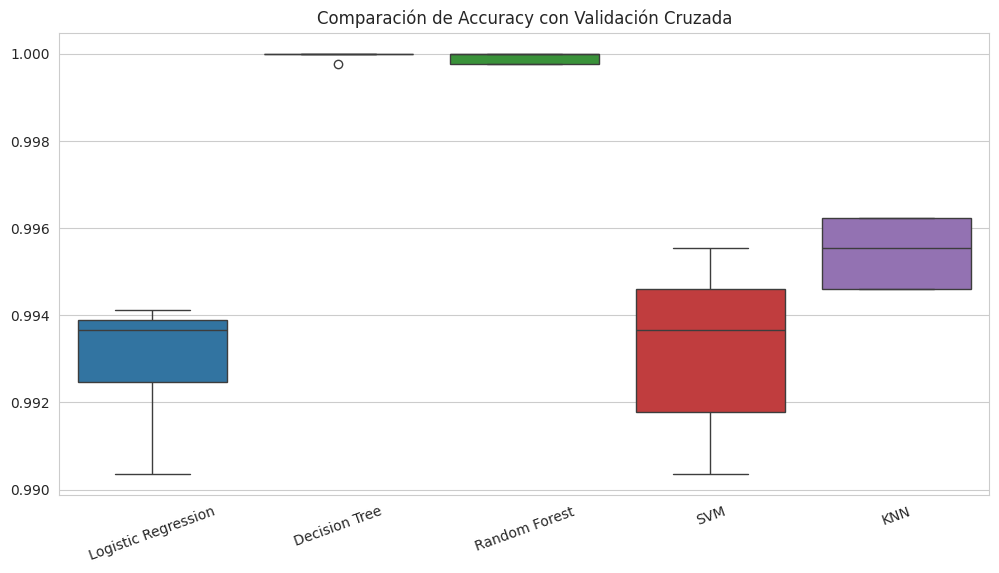

In [9]:
cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(12,6))

sns.boxplot(data=cv_df)

plt.title("Comparación de Accuracy con Validación Cruzada")

plt.xticks(rotation=20)

plt.show()

# Evaluación con Métricas

In [10]:
evaluation_results = []

predictions_store = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    predictions_store[name] = predictions

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, average="weighted"),
        "Recall": recall_score(y_test, predictions, average="weighted"),
        "F1-Score": f1_score(y_test, predictions, average="weighted")
    })

results_df = pd.DataFrame(evaluation_results)

results_df.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000
4,KNN,0.995535,0.995546,0.995535,0.995534
0,Logistic Regression,0.994125,0.994147,0.994125,0.994112
3,SVM,0.993655,0.993668,0.993655,0.993634


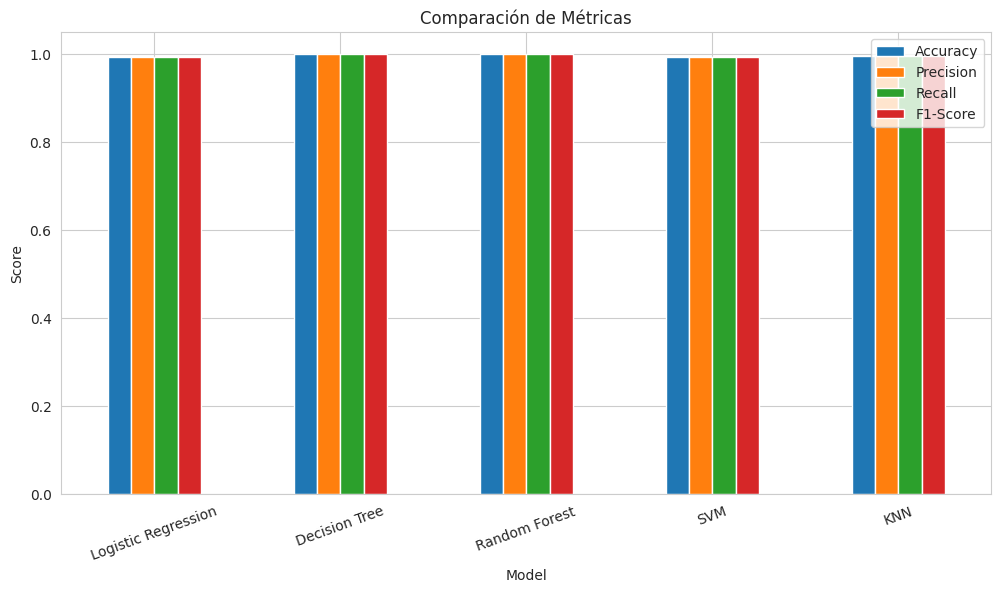

In [11]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparación de Métricas")

plt.ylabel("Score")

plt.xticks(rotation=20)

plt.show()

# Matrices de Confusión

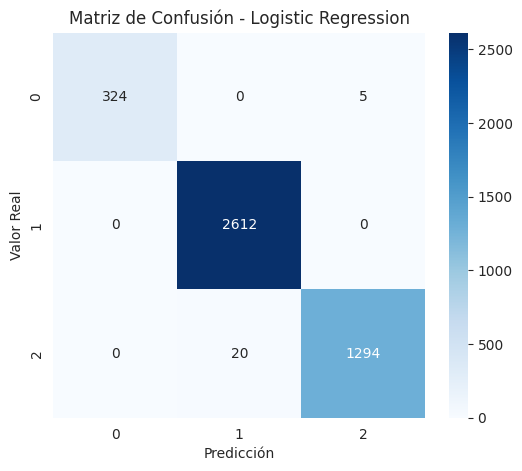

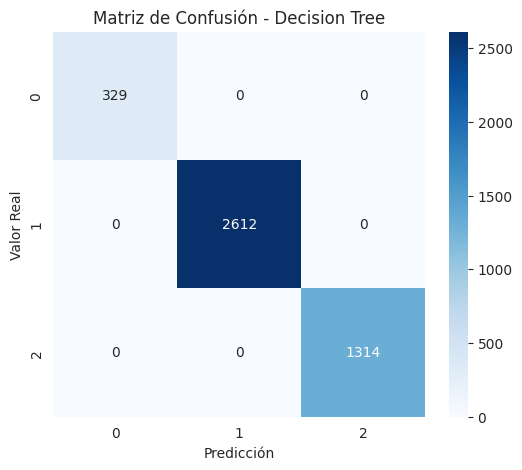

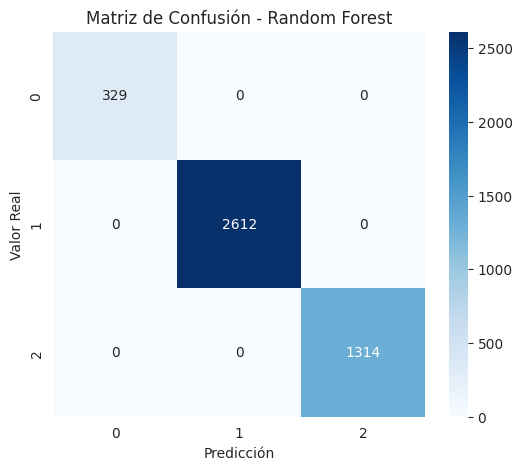

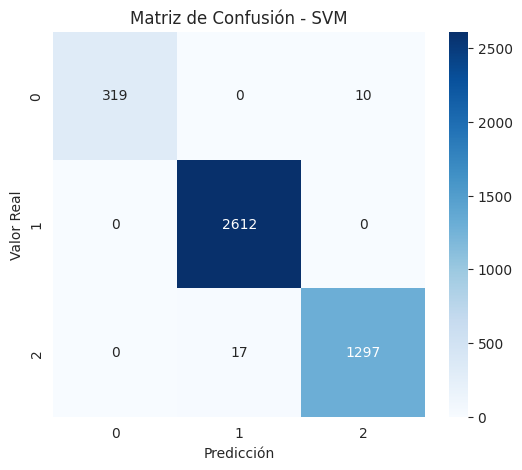

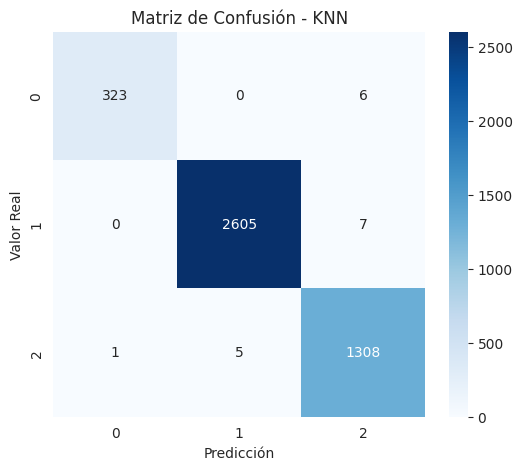

In [12]:
for name, predictions in predictions_store.items():

    plt.figure(figsize=(6,5))

    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Matriz de Confusión - {name}")

    plt.xlabel("Predicción")
    plt.ylabel("Valor Real")

    plt.show()

# Classification Report

In [13]:
for name, predictions in predictions_store.items():

    print("="*70)
    print(name)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=encoder.classes_
        )
    )

Logistic Regression
                 precision    recall  f1-score   support

  High Activity       1.00      0.98      0.99       329
   Low Activity       0.99      1.00      1.00      2612
Medium Activity       1.00      0.98      0.99      1314

       accuracy                           0.99      4255
      macro avg       1.00      0.99      0.99      4255
   weighted avg       0.99      0.99      0.99      4255

Decision Tree
                 precision    recall  f1-score   support

  High Activity       1.00      1.00      1.00       329
   Low Activity       1.00      1.00      1.00      2612
Medium Activity       1.00      1.00      1.00      1314

       accuracy                           1.00      4255
      macro avg       1.00      1.00      1.00      4255
   weighted avg       1.00      1.00      1.00      4255

Random Forest
                 precision    recall  f1-score   support

  High Activity       1.00      1.00      1.00       329
   Low Activity       1.00      1

# Conclusiones Técnicas

## Hallazgos
- Se compararon múltiples modelos supervisados.
- Se aplicó validación cruzada robusta.
- Accuracy, Precision, Recall y F1 permitieron evaluación integral.
- Las matrices de confusión mostraron errores específicos por modelo.

## Impacto
- Permite seleccionar el modelo más estable.
- Reduce riesgo de overfitting.
- Entrega base sólida para optimización de hiperparámetros.